In [33]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models(exclude=['envelope_log_8band', 'envelope_log_onset'])

In [43]:
# ------------------------------------------------
# Parameters
# ------------------------------------------------
subject_example = 'S13'  # pick first subject

# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r2_values = {model: [] for model in models}
rmse_values = {model: [] for model in models}

r_values_universal = {model: [] for model in models}
r2_values_universal = {model: [] for model in models}
rmse_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {model: eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')
                  for model in models}

# ------------------------------------------------
# Loop over subjects and models
# ------------------------------------------------
for subject in SUBJECTS:
    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:
        predictors = subject_model_predictors[subject][model]

        # --- Subject decoder ---
        trf_sub = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle')
        pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
        stim_sub = predictors[0]

        r_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1])
        r2_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1]**2)
        rmse_values[model].append(np.sqrt(np.mean((stim_sub.x - pred_sub)**2)))

        # --- Universal decoder ---
        trf_univ = universal_trfs[model]
        pred_univ = eelbrain.convolve(trf_univ, eeg).x
        stim_univ = predictors[0]

        r_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1])
        r2_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1]**2)
        rmse_values_universal[model].append(np.sqrt(np.mean((stim_univ.x - pred_univ)**2)))

# ------------------------------------------------
# Store time series for example subject
# ------------------------------------------------
eeg_example = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject_example}concatenated_eeg.pickle')
time_series_example = {}

for model in ['envelope_log', 'envelope_onset']:
    # subject TRF
    trf_sub = eelbrain.load.unpickle(TRF_DIR / subject_example / f'{subject_example} decoder-{model}.pickle')
    pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg_example).x
    if pred_sub.ndim > 1:
        pred_sub = pred_sub[0]
    time_series_example[f'Subj {model}'] = pred_sub

    # universal TRF
    trf_univ = universal_trfs[model]
    pred_univ = eelbrain.convolve(trf_univ, eeg_example).x
    if pred_univ.ndim > 1:
        pred_univ = pred_univ[0]
    time_series_example[f'Univ {model}'] = pred_univ

# true envelope
true_env_example = subject_model_predictors[subject_example]['envelope_log'][0].x
time_example = subject_model_predictors[subject_example]['envelope_log'][0].time.times

print("✅ All values computed and stored.")

✅ All values computed and stored.


/var/folders/y0/p95jrf3s35b2tqj_rnj24xjr0000gn/T/ipykernel_89271/4288852109.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


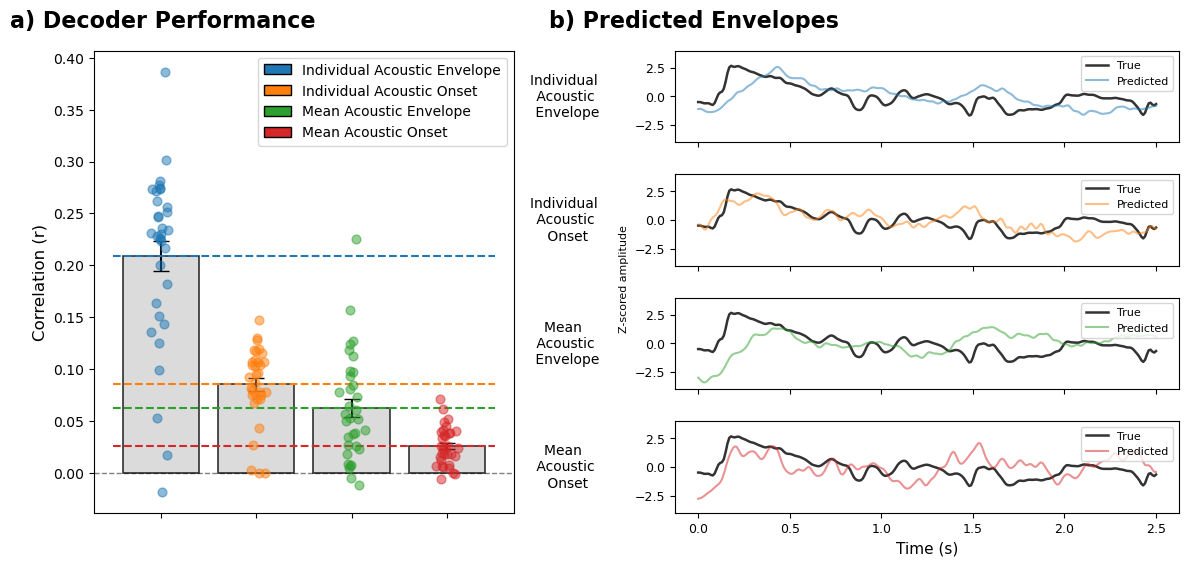

In [62]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec
import seaborn as sns
from matplotlib.patches import Patch

t_max = 2.5  # seconds to show in panel B

# ------------------------------------------------
# Color palette for consistency
# ------------------------------------------------
trace_colors = sns.color_palette("tab10", n_colors=4)  # for panel B traces
label_colors = trace_colors  # map to panel A scatter points
color_alpha = 0.5

# ------------------------------------------------
# PANEL A: Bar plot with grey bars, semi-transparent scatter, horizontal mean lines
# ------------------------------------------------
'''
labels = ['Subj Log', 'Subj Onset', 'Univ Log', 'Univ Onset']
label_name = {'Subj Log': 'Individual Acoustic Envelope', 
              'Subj Onset': 'Individual Acoustic Onset', 
              'Univ Log': 'Mean Acoustic Envelope', 
              'Univ Onset': 'Mean Acoustic Onset'}
'''
labels = ['Individual Acoustic Envelope', 'Individual Acoustic Onset', 'Mean Acoustic Envelope', 'Mean Acoustic Onset']
data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.35)

# Bar plot
ax0 = fig.add_subplot(gs[0])
x = np.arange(len(labels))

# Bars (grey, semi-transparent)
ax0.bar(x, means, yerr=sems, capsize=6, color='lightgrey', edgecolor='k', linewidth=1.2, alpha=0.8, zorder=1)

for i, d in enumerate(data):
    # Horizontal dashed line across the plot at the mean
    ax0.hlines(means[i], xmin=-0.5, xmax=len(labels)-0.5, 
               color=trace_colors[i], linestyle='--', linewidth=1.5, zorder=2)
    
    # Scatter points
    ax0.scatter(np.random.normal(i, 0.05, size=len(d)), d, 
                color=trace_colors[i], alpha=color_alpha, s=40, zorder=3)

ax0.set_xticks(x)
ax0.set_xticklabels([], rotation=25)
ax0.set_ylabel('Correlation (r)', fontsize=12)
#ax0.set_title('Panel A: Decoder Performance', fontsize=14)
ax0.axhline(0, linestyle='--', color='gray', linewidth=1, zorder=0)

# Legend inside panel A (upper right)
legend_elements = [Patch(facecolor=trace_colors[i], edgecolor='k', label=labels[i]) for i in range(4)]
ax0.legend(handles=legend_elements, fontsize=10, loc='upper right')

# Add label "a)"
ax0.text(-0.2, 1.05, 'a) Decoder Performance', transform=ax0.transAxes, fontsize=16, fontweight='bold')

# ------------------------------------------------
# PANEL B: Four stacked mini-plots with z-scored signals and transparency
# ------------------------------------------------
mask = time_example <= t_max
time_50 = time_example[mask]
env_50 = true_env_example[mask]

gs_right = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[1], hspace=0.35)
plot_keys = ['Subj envelope_log', 'Subj envelope_onset', 'Univ envelope_log', 'Univ envelope_onset']

for i, key in enumerate(plot_keys):
    ax = fig.add_subplot(gs_right[i])
    if 'log' in key.lower():
        pred = time_series_example[f'Subj envelope_log'] if 'Subj' in key else time_series_example[f'Univ envelope_log']
    else:
        pred = time_series_example[f'Subj envelope_onset'] if 'Subj' in key else time_series_example[f'Univ envelope_onset']

    # z-score standardization
    pred_masked = pred[:len(env_50)]
    pred_z = (pred_masked - np.mean(pred_masked)) / np.std(pred_masked)
    env_z = (env_50 - np.mean(env_50)) / np.std(env_50)

    ax.plot(time_50, env_z, label='True', color='black', linewidth=1.8, alpha=0.8)
    ax.plot(time_50, pred_z, label='Predicted', color=trace_colors[i], linewidth=1.5, alpha=color_alpha)
    
    labels = ['Individual \n Acoustic \n Envelope', 'Individual \n Acoustic \n Onset', 'Mean \n Acoustic \n Envelope', 'Mean \n Acoustic \n Onset']
    ax.set_ylabel(labels[i], rotation=0, labelpad=50, fontsize=10, va='center')
    
    if i == 3:
        ax.set_xlabel('Time (s)', fontsize=11)
    else:
        ax.set_xticklabels([])
    
    ax.set_ylim([-4,4])
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)
    ax.legend(fontsize=8, loc='upper right')

# Shared y-axis label for all 4 mini-plots
fig.text(0.5, 0.5, 'Z-scored amplitude', va='center', rotation=90, fontsize=8)

# Add label "b)"
ax = fig.add_subplot(gs[1])
ax.text(-0.25, 1.05, 'b) Predicted Envelopes', transform=ax.transAxes, fontsize=16, fontweight='bold')
ax.axis('off')  # hide this temporary axis

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


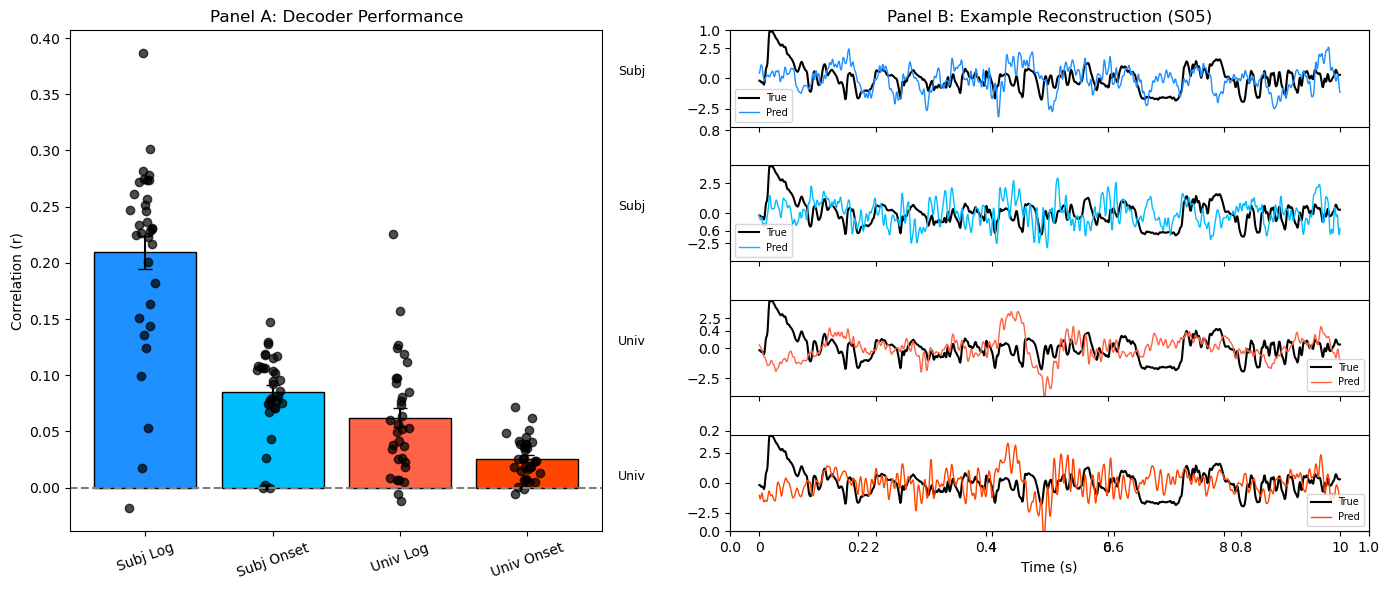

In [5]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec

# ------------------------------------------------
# Parameters
# ------------------------------------------------
subject_example = SUBJECTS[0]  # pick first subject
t_max = 10  # seconds to show in panel B

# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r2_values = {model: [] for model in models}
rmse_values = {model: [] for model in models}

r_values_universal = {model: [] for model in models}
r2_values_universal = {model: [] for model in models}
rmse_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {model: eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')
                  for model in models}

# ------------------------------------------------
# Loop over subjects and models
# ------------------------------------------------
for subject in SUBJECTS:
    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:
        predictors = subject_model_predictors[subject][model]

        # --- Subject decoder ---
        trf_sub = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle')
        pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
        stim_sub = predictors[0]

        r_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1])
        r2_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1]**2)
        rmse_values[model].append(np.sqrt(np.mean((stim_sub.x - pred_sub)**2)))

        # --- Universal decoder ---
        trf_univ = universal_trfs[model]
        pred_univ = eelbrain.convolve(trf_univ, eeg).x
        stim_univ = predictors[0]

        r_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1])
        r2_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1]**2)
        rmse_values_universal[model].append(np.sqrt(np.mean((stim_univ.x - pred_univ)**2)))

# ------------------------------------------------
# PANEL A: Bar plot with colors and scatter
# ------------------------------------------------
labels = ['Subj Log', 'Subj Onset', 'Univ Log', 'Univ Onset']
data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

# Bar plot
ax0 = fig.add_subplot(gs[0])
x = np.arange(len(labels))
colors = ['dodgerblue', 'deepskyblue', 'tomato', 'orangered']
ax0.bar(x, means, yerr=sems, capsize=5, color=colors, edgecolor='k')
for i, d in enumerate(data):
    ax0.scatter(np.random.normal(i, 0.05, size=len(d)), d, color='k', alpha=0.7)
ax0.set_xticks(x)
ax0.set_xticklabels(labels, rotation=20)
ax0.set_ylabel('Correlation (r)')
ax0.set_title('Panel A: Decoder Performance')
ax0.axhline(0, linestyle='--', color='gray')

# ------------------------------------------------
# PANEL B: Four stacked mini-plots with z-scored signals
# ------------------------------------------------
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject_example}concatenated_eeg.pickle')
time_series = {}

for model in ['envelope_log', 'envelope_onset']:
    # subject TRF
    trf_sub = eelbrain.load.unpickle(TRF_DIR / subject_example / f'{subject_example} decoder-{model}.pickle')
    pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
    if pred_sub.ndim > 1:
        pred_sub = pred_sub[0]
    time_series[f'Subj {model}'] = pred_sub

    # universal TRF
    trf_univ = universal_trfs[model]
    pred_univ = eelbrain.convolve(trf_univ, eeg).x
    if pred_univ.ndim > 1:
        pred_univ = pred_univ[0]
    time_series[f'Univ {model}'] = pred_univ

# true envelope
true_env = subject_model_predictors[subject_example]['envelope_log'][0].x
time = subject_model_predictors[subject_example]['envelope_log'][0].time.times
mask = time <= t_max
time_50 = time[mask]
env_50 = true_env[mask]

ax1 = fig.add_subplot(gs[1])
gs_right = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[1], hspace=0.4)
plot_keys = ['Subj envelope_log', 'Subj envelope_onset', 'Univ envelope_log', 'Univ envelope_onset']
colors_pred = ['dodgerblue', 'deepskyblue', 'tomato', 'orangered']

for i, key in enumerate(plot_keys):
    ax = fig.add_subplot(gs_right[i])
    if 'Log' in key or 'log' in key:
        pred = time_series[f'Subj envelope_log'] if 'Subj' in key else time_series[f'Univ envelope_log']
    else:
        pred = time_series[f'Subj envelope_onset'] if 'Subj' in key else time_series[f'Univ envelope_onset']

    # z-score standardization
    pred_masked = pred[:len(env_50)]
    pred_z = (pred_masked - np.mean(pred_masked)) / np.std(pred_masked)
    env_z = (env_50 - np.mean(env_50)) / np.std(env_50)

    ax.plot(time_50, env_z, label='True', color='black', linewidth=1.5)
    ax.plot(time_50, pred_z, label='Pred', color=colors_pred[i], linewidth=1)
    ax.set_ylabel(key.split()[0], rotation=0, labelpad=40, fontsize=9)
    if i != 3:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (s)')
    ax.set_ylim([-4,4])
    ax.legend(fontsize=7)

ax1.set_title(f'Panel B: Example Reconstruction ({subject_example})')
plt.tight_layout()
plt.show()

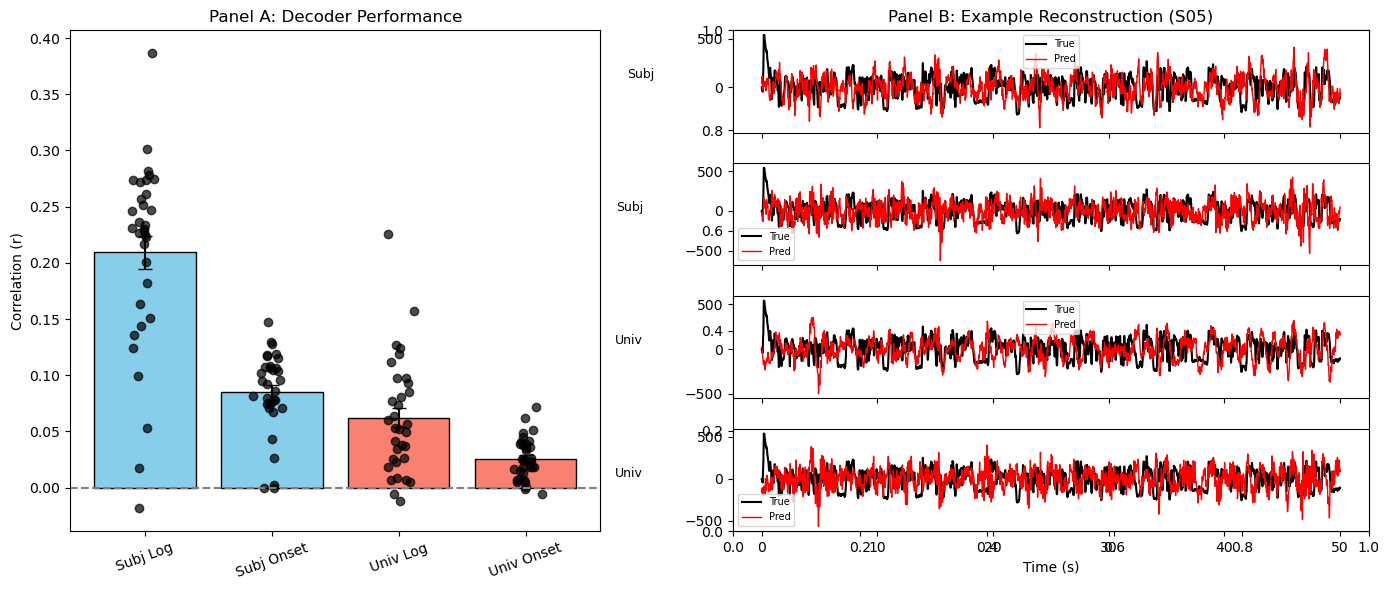

In [4]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Parameters
# ------------------------------------------------
subject_example = SUBJECTS[0]  # pick first subject
t_max = 50  # seconds to show in panel B

# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r2_values = {model: [] for model in models}
rmse_values = {model: [] for model in models}

r_values_universal = {model: [] for model in models}
r2_values_universal = {model: [] for model in models}
rmse_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {model: eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')
                  for model in models}

# ------------------------------------------------
# Loop over subjects and models
# ------------------------------------------------
for subject in SUBJECTS:
    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:
        predictors = subject_model_predictors[subject][model]

        # --- Subject decoder ---
        trf_sub = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle')
        pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
        stim_sub = predictors[0]

        # correlation
        r_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1])
        r2_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1]**2)
        rmse_values[model].append(np.sqrt(np.mean((stim_sub.x - pred_sub)**2)))

        # --- Universal decoder ---
        trf_univ = universal_trfs[model]
        pred_univ = eelbrain.convolve(trf_univ, eeg).x
        stim_univ = predictors[0]

        r_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1])
        r2_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1]**2)
        rmse_values_universal[model].append(np.sqrt(np.mean((stim_univ.x - pred_univ)**2)))

# ------------------------------------------------
# PANEL A: Bar plot with scatter and error bars
# ------------------------------------------------
labels = ['Subj Log', 'Subj Onset', 'Univ Log', 'Univ Onset']
data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

fig = plt.figure(figsize=(14,6))
# GridSpec to allocate more space for stacked plots
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

# Bar plot panel
ax0 = fig.add_subplot(gs[0])
x = np.arange(len(labels))
colors = ['skyblue', 'skyblue', 'salmon', 'salmon']
ax0.bar(x, means, yerr=sems, capsize=5, color=colors, edgecolor='k')
for i, d in enumerate(data):
    ax0.scatter(np.random.normal(i, 0.05, size=len(d)), d, color='k', alpha=0.7)
ax0.set_xticks(x)
ax0.set_xticklabels(labels, rotation=20)
ax0.set_ylabel('Correlation (r)')
ax0.set_title('Panel A: Decoder Performance')
ax0.axhline(0, linestyle='--', color='gray')

# ------------------------------------------------
# PANEL B: Four stacked mini-plots
# ------------------------------------------------
# Load EEG and predictions for the example subject
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject_example}concatenated_eeg.pickle')
time_series = {}
for model in ['envelope_log', 'envelope_onset']:
    # subject TRF
    trf_sub = eelbrain.load.unpickle(TRF_DIR / subject_example / f'{subject_example} decoder-{model}.pickle')
    pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
    if pred_sub.ndim > 1:
        pred_sub = pred_sub[0]
    time_series[f'Subj {model}'] = pred_sub

    # universal TRF
    trf_univ = universal_trfs[model]
    pred_univ = eelbrain.convolve(trf_univ, eeg).x
    if pred_univ.ndim > 1:
        pred_univ = pred_univ[0]
    time_series[f'Univ {model}'] = pred_univ

# true envelope
true_env = subject_model_predictors[subject_example]['envelope_log'][0].x
time = subject_model_predictors[subject_example]['envelope_log'][0].time.times
mask = time <= t_max
time_50 = time[mask]
env_50 = true_env[mask]

ax1 = fig.add_subplot(gs[1])
# Make 4 stacked axes inside the same right panel
from matplotlib.gridspec import GridSpecFromSubplotSpec
gs_right = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[1], hspace=0.3)
keys = ['Subj envelope_log', 'Subj envelope_onset', 'Univ envelope_log', 'Univ envelope_onset']

for i, key in enumerate(keys):
    ax = fig.add_subplot(gs_right[i])
    if 'Log' in key or 'log' in key:
        pred = time_series[f'Subj envelope_log'] if 'Subj' in key else time_series[f'Univ envelope_log']
    else:
        pred = time_series[f'Subj envelope_onset'] if 'Subj' in key else time_series[f'Univ envelope_onset']

    pred_masked = pred[:len(env_50)]
    pred_scaled = pred_masked * (env_50.std() / pred_masked.std())
    ax.plot(time_50, env_50, label='True', linewidth=1.5, color='black')
    ax.plot(time_50, pred_scaled, label='Pred', linewidth=1, color='red')
    ax.set_ylabel(key.split()[0], rotation=0, labelpad=40, fontsize=9)
    if i != 3:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (s)')
    ax.legend(fontsize=7)

ax1.set_title(f'Panel B: Example Reconstruction ({subject_example})')
plt.tight_layout()
plt.show()

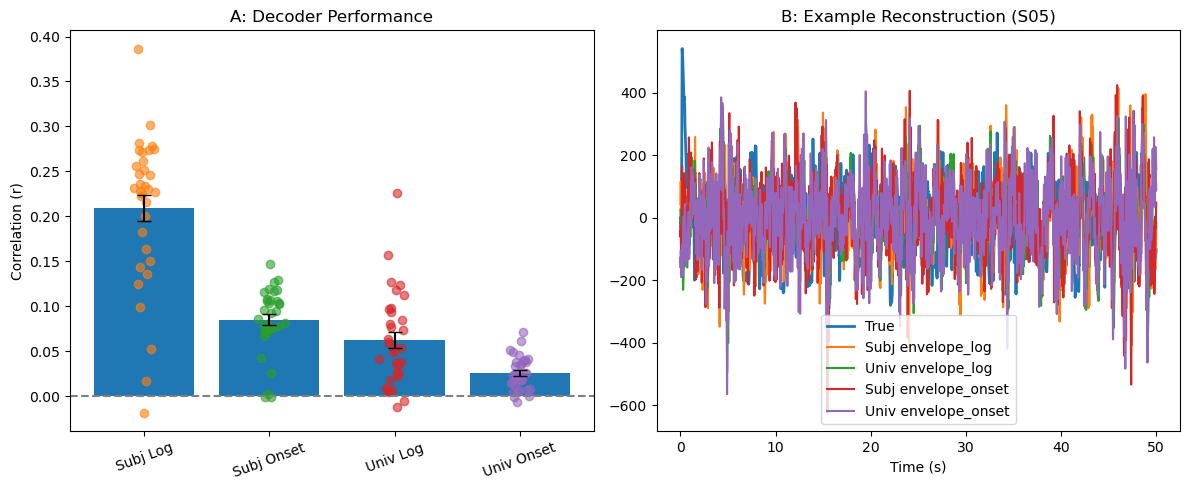

In [3]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Parameters
# ------------------------------------------------
subject_example = SUBJECTS[0]  # pick first subject
t_max = 50  # seconds to show in panel B

# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r2_values = {model: [] for model in models}
rmse_values = {model: [] for model in models}

r_values_universal = {model: [] for model in models}
r2_values_universal = {model: [] for model in models}
rmse_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {model: eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')
                  for model in models}

# ------------------------------------------------
# Loop over subjects and models
# ------------------------------------------------
for subject in SUBJECTS:
    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:
        predictors = subject_model_predictors[subject][model]

        # --- Subject decoder ---
        trf_sub = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle')
        pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
        stim_sub = predictors[0]

        # correlation
        r_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1])
        r2_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1]**2)
        rmse_values[model].append(np.sqrt(np.mean((stim_sub.x - pred_sub)**2)))

        # --- Universal decoder ---
        trf_univ = universal_trfs[model]
        pred_univ = eelbrain.convolve(trf_univ, eeg).x
        stim_univ = predictors[0]

        r_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1])
        r2_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1]**2)
        rmse_values_universal[model].append(np.sqrt(np.mean((stim_univ.x - pred_univ)**2)))

# ------------------------------------------------
# PANEL A: Bar plot (correlation)
# ------------------------------------------------
labels = ['Subj Log', 'Subj Onset', 'Univ Log', 'Univ Onset']
data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

ax = axes[0]
x = np.arange(len(labels))
ax.bar(x, means, yerr=sems, capsize=5)
for i, d in enumerate(data):
    ax.scatter(np.random.normal(i, 0.05, size=len(d)), d, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel('Correlation (r)')
ax.set_title('A: Decoder Performance')
ax.axhline(0, linestyle='--', color='gray')

# PANEL B: Time series example
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject_example}concatenated_eeg.pickle')
time_series = {}

for model in ['envelope_log', 'envelope_onset']:
    # subject TRF
    trf_sub = eelbrain.load.unpickle(TRF_DIR / subject_example / f'{subject_example} decoder-{model}.pickle')
    pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
    if pred_sub.ndim > 1:
        pred_sub = pred_sub[0]  # pick first channel
    time_series[f'Subj {model}'] = pred_sub

    # universal TRF
    trf_univ = universal_trfs[model]
    pred_univ = eelbrain.convolve(trf_univ, eeg).x
    if pred_univ.ndim > 1:
        pred_univ = pred_univ[0]  # pick first channel
    time_series[f'Univ {model}'] = pred_univ

# true envelope
true_env = subject_model_predictors[subject_example]['envelope_log'][0].x
time = subject_model_predictors[subject_example]['envelope_log'][0].time.times

# mask first t_max seconds
mask = time <= t_max
time_50 = time[mask]
env_50 = true_env[mask]

ax = axes[1]
ax.plot(time_50, env_50, label='True', linewidth=2)

for key, pred in time_series.items():
    pred_masked = pred[:len(env_50)]
    pred_scaled = pred_masked * (env_50.std() / pred_masked.std())
    ax.plot(time_50, pred_scaled, label=key)

ax.set_xlabel('Time (s)')
ax.set_title(f'B: Example Reconstruction ({subject_example})')
ax.legend()
plt.tight_layout()
plt.show()